In [2]:
import json
import pandas as pd
import matplotlib.pyplot as plt

# Load test samples
with open("../data/test_samples.json", "r", encoding="utf-8") as f:
    test_data = json.load(f)

# Load evaluation data
with open("../data/evaluation_data.json", "r", encoding="utf-8") as f:
    eval_data = json.load(f)

# Convert to DataFrame
test_df = pd.DataFrame(test_data["reviews"])
eval_rows = []
for r in eval_data["labeled_reviews"]:
    for asp in r["aspects"]:
        eval_rows.append({
            "text": r["text"],
            "aspect": asp["aspect"],
            "sentiment": asp["sentiment"]
        })
eval_df = pd.DataFrame(eval_rows)

print("Test samples shape:", test_df.shape)
print("Evaluation shape:", eval_df.shape)
test_df.head()


Test samples shape: (15, 3)
Evaluation shape: (16, 3)


,text,stars,review_id
0,"If you decide to eat here, just be aware it is...",3,test_001
1,Family diner. Had the buffet. Eclectic assortm...,3,test_002
2,"Wow! Yummy, different, delicious. Our favorite...",5,test_003
3,Cute interior and owner gave us tour of upcomi...,4,test_004
4,I am a long term frequent customer of this est...,1,test_005


#### **Review length analysis**

📊 Average review length (test): 38.47
📊 Average review length (eval): 18.0


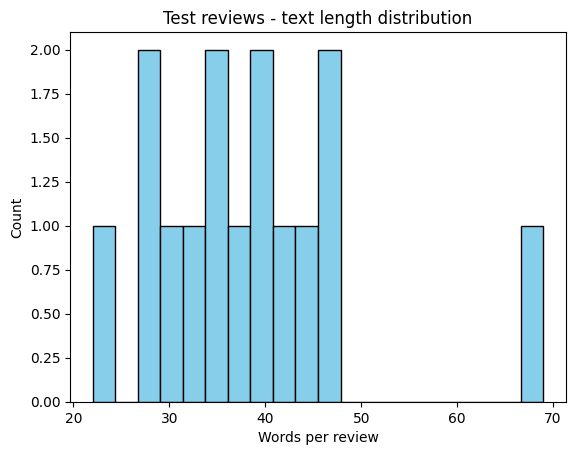

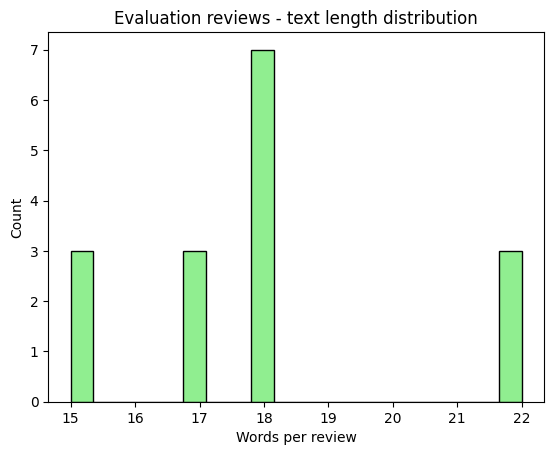

In [8]:
test_df["length"] = test_df["text"].str.split().apply(len)
eval_df["length"] = eval_df["text"].str.split().apply(len)

print(" Average review length (test):", round(test_df["length"].mean(), 2))
print(" Average review length (eval):", round(eval_df["length"].mean(), 2))

plt.hist(test_df["length"], bins=20, color="skyblue", edgecolor="black")
plt.title("Test reviews - text length distribution")
plt.xlabel("Words per review")
plt.ylabel("Count")
plt.show()

plt.hist(eval_df["length"], bins=20, color="lightgreen", edgecolor="black")
plt.title("Evaluation reviews - text length distribution")
plt.xlabel("Words per review")
plt.ylabel("Count")
plt.show()

#### **Star ratings distribution**

Average rating: 3.67


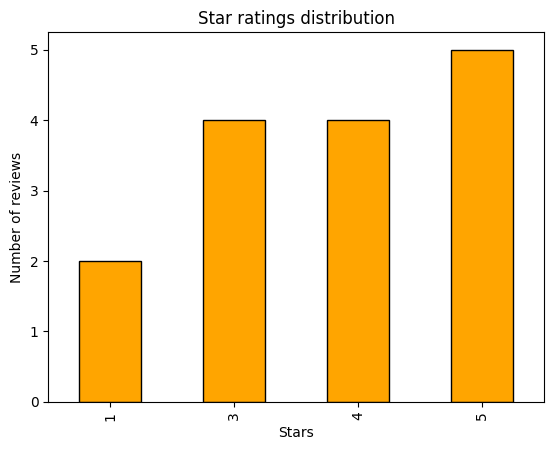

In [9]:
if "stars" in test_df.columns:
    print("Average rating:", round(test_df["stars"].mean(), 2))
    test_df["stars"].value_counts().sort_index().plot(kind="bar", color="orange", edgecolor="black")
    plt.title("Star ratings distribution")
    plt.xlabel("Stars")
    plt.ylabel("Number of reviews")
    plt.show()
else:
    print("No stars column available.")

#### **Sentiment distribution**

 Sentiment counts:
sentiment
positive    10
negative     6
Name: count, dtype: int64


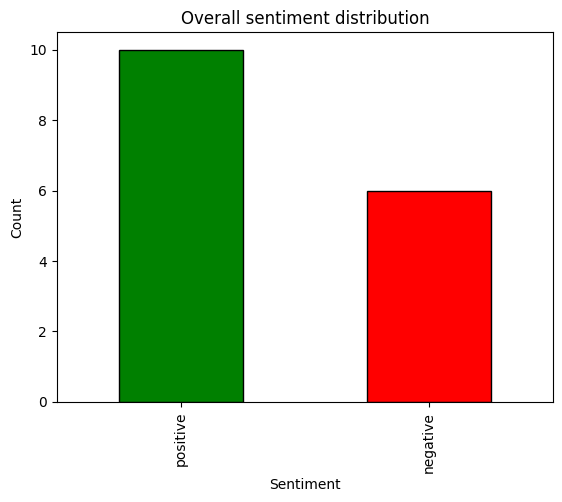


 Sentiment percentages:
sentiment
positive    62.5
negative    37.5
Name: count, dtype: float64


In [10]:
sent_counts = eval_df["sentiment"].value_counts()
print(" Sentiment counts:")
print(sent_counts)

sent_counts.plot(kind="bar", color=["green", "red", "gray"], edgecolor="black")
plt.title("Overall sentiment distribution")
plt.xlabel("Sentiment")
plt.ylabel("Count")
plt.show()

print("\n Sentiment percentages:")
print((sent_counts / sent_counts.sum() * 100).round(2))

#### **Most common aspects**

Top 10 aspects:
aspect
food          3
waitstaff     2
service       2
lamb curry    1
korma         1
naan          1
staff         1
prices        1
quality       1
waffle        1
Name: count, dtype: int64


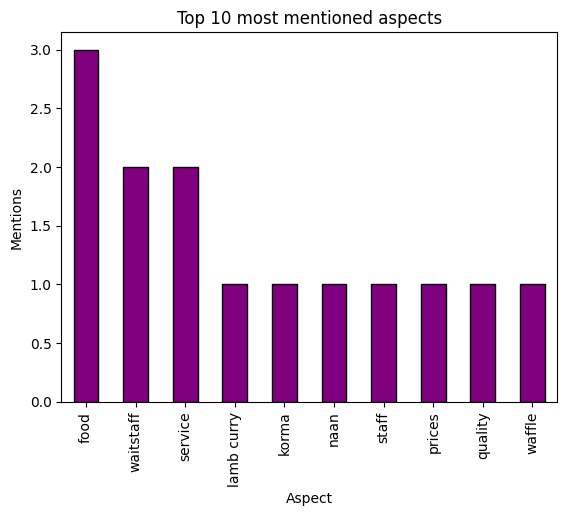

In [11]:
aspect_counts = eval_df["aspect"].value_counts()
print("Top 10 aspects:")
print(aspect_counts.head(10))

aspect_counts.head(10).plot(kind="bar", color="purple", edgecolor="black")
plt.title("Top 10 most mentioned aspects")
plt.xlabel("Aspect")
plt.ylabel("Mentions")
plt.show()

#### **Most positive and most negative aspects**

Top 5 positive aspects:
aspect
food          2
waitstaff     2
lamb curry    1
korma         1
naan          1
Name: count, dtype: int64
Top 5 negative aspects:
aspect
service    2
food       1
staff      1
prices     1
quality    1
Name: count, dtype: int64


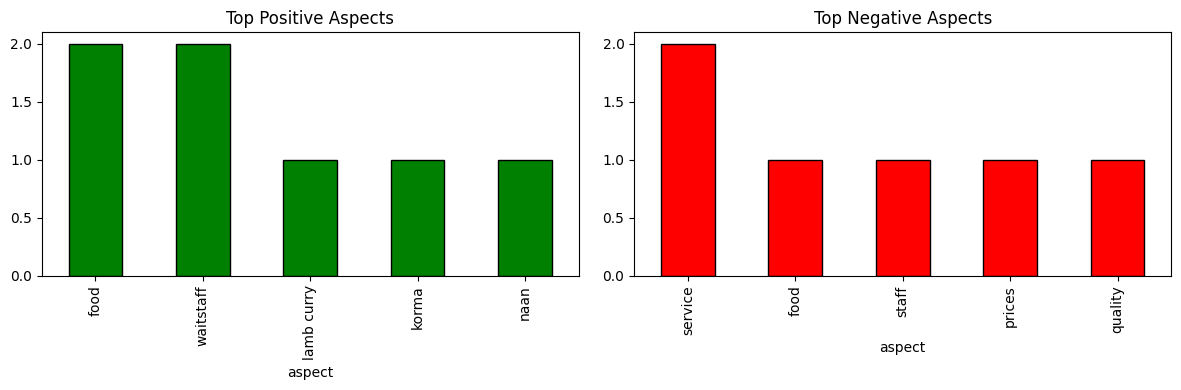

In [12]:
pos_aspects = eval_df[eval_df["sentiment"] == "positive"]["aspect"].value_counts()
neg_aspects = eval_df[eval_df["sentiment"] == "negative"]["aspect"].value_counts()

print("Top 5 positive aspects:")
print(pos_aspects.head(5))
print("Top 5 negative aspects:")
print(neg_aspects.head(5))

fig, axes = plt.subplots(1, 2, figsize=(12,4))
pos_aspects.head(5).plot(kind="bar", ax=axes[0], color="green", edgecolor="black", title="Top Positive Aspects")
neg_aspects.head(5).plot(kind="bar", ax=axes[1], color="red", edgecolor="black", title="Top Negative Aspects")
plt.tight_layout()
plt.show()


#### **Aspects per review**

Average aspects per review: 3.2
Max aspects in a review: 4


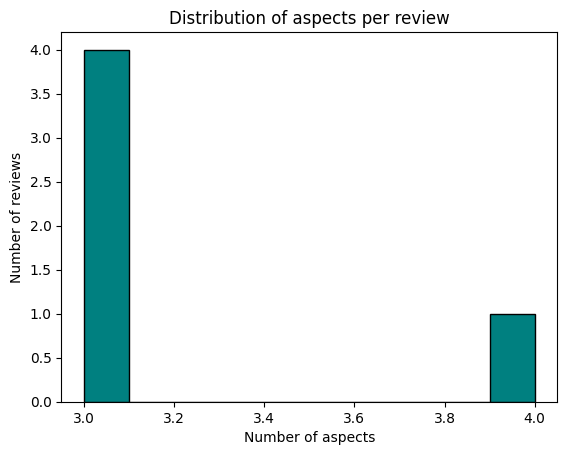

In [13]:
aspects_per_text = eval_df.groupby("text")["aspect"].nunique()
print("Average aspects per review:", round(aspects_per_text.mean(), 2))
print("Max aspects in a review:", aspects_per_text.max())

plt.hist(aspects_per_text, bins=10, color="teal", edgecolor="black")
plt.title("Distribution of aspects per review")
plt.xlabel("Number of aspects")
plt.ylabel("Number of reviews")
plt.show()


#### **Sentiment ratio per aspect**

Aspects with highest positive ratio:
sentiment   positive  negative
aspect                        
breakfast   1.000000  0.000000
gnocchi     1.000000  0.000000
korma       1.000000  0.000000
lamb curry  1.000000  0.000000
waffle      1.000000  0.000000
naan        1.000000  0.000000
waitstaff   1.000000  0.000000
food        0.666667  0.333333
quality     0.000000  1.000000
prices      0.000000  1.000000


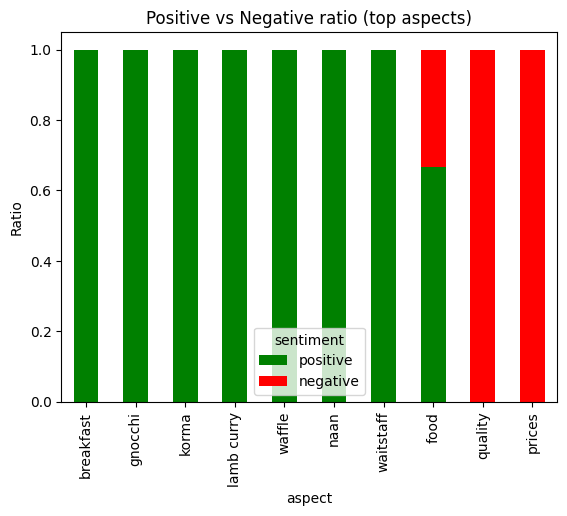

In [14]:
aspect_sentiment = eval_df.groupby("aspect")["sentiment"].value_counts(normalize=True).unstack().fillna(0)
aspect_sentiment = aspect_sentiment.sort_values("positive", ascending=False)

print("Aspects with highest positive ratio:")
print(aspect_sentiment.head(10)[["positive", "negative"]])

aspect_sentiment.head(10)[["positive", "negative"]].plot(kind="bar", stacked=True, color=["green", "red"])
plt.title("Positive vs Negative ratio (top aspects)")
plt.ylabel("Ratio")
plt.show()
